In [1]:
# ============================================================
#  MODELO 2: ¿QUÉ INGREDIENTES/MARCAS SE ASOCIAN CON
#            MEJORES VALORACIONES Y RECOMENDACIONES?
#            (Clasificación de is_recommended)
# ============================================================

import pandas as pd
import numpy as np
import os
import json

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [12]:
# ------------------------------------------------------------
# Carga de datos
# ------------------------------------------------------------

data = "reviews_df_cleaned_sample_50000.csv"

df = pd.read_csv(data)

print("Shape original:", df.shape)
print(df.head())

# Nos aseguramos de que las columnas clave existan
required_cols = ["review_text", "is_recommended"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas en el dataset: {missing}")

Shape original: (50000, 19)
   Unnamed: 0   author_id  rating  is_recommended  helpfulness  \
0       90628  2087480633       5             1.0         0.00   
1      203463  1856251916       4             1.0         0.00   
2       92859  5728295801       2             0.0         0.85   
3      111863  1672687375       1             0.0         0.90   
4      233800  1739343617       5             1.0         1.00   

   total_feedback_count  total_neg_feedback_count  total_pos_feedback_count  \
0                     0                         0                         0   
1                     0                         0                         0   
2                    20                         3                        17   
3                    20                         2                        18   
4                     1                         0                         1   

  submission_time                                        review_text  \
0      2021-05-16  I receive

/tmp/ipython-input-1113927746.py:7: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data)


In [13]:
# ---------------------------------------------
# LIMPIEZA
# ---------------------------------------------

print("Shape original:", df.shape)

# 1. Eliminamos filas sin texto (is_recommended NO tiene)
df = df.dropna(subset=["review_text"])
print("Shape después de limpiar review_text:", df.shape)

# 2. Convertimos is_recommended a entero 0/1
df["is_recommended"] = df["is_recommended"].astype(float).round().astype(int)

print("\nDistribución final de is_recommended:")
print(df["is_recommended"].value_counts())


Shape original: (50000, 19)
Shape después de limpiar review_text: (50000, 19)

Distribución final de is_recommended:
is_recommended
1    42047
0     7953
Name: count, dtype: int64


In [14]:
X_text = df["review_text"].astype(str)
y = df["is_recommended"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [15]:
# ------------------------------------------------------------
# Vectorización TF-IDF
# ------------------------------------------------------------

vectorizer = TfidfVectorizer(
    max_features=20_000,   # número máximo de palabras/características
    ngram_range=(1, 2),    # unigramas y bigramas
    min_df=5,              # al menos en 5 documentos
    stop_words="english"   # remover stopwords en inglés
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print("Shape TF-IDF train:", X_train_tfidf.shape)
print("Shape TF-IDF test :", X_test_tfidf.shape)

Shape TF-IDF train: (40000, 20000)
Shape TF-IDF test : (10000, 20000)


In [16]:
# ------------------------------------------------------------
# Entrenamiento del modelo XGBoost (clasificación binaria)
# ------------------------------------------------------------

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

xgb_clf.fit(X_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [17]:
y_pred = xgb_clf.predict(X_test_tfidf)
y_proba = xgb_clf.predict_proba(X_test_tfidf)[:, 1]

In [18]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.9072
Precision: 0.9146436093559472
Recall: 0.9812106076822452
F1-score: 0.9467584624211131

Classification Report:
              precision    recall  f1-score   support

           0     0.8386    0.5160    0.6389      1591
           1     0.9146    0.9812    0.9468      8409

    accuracy                         0.9072     10000
   macro avg     0.8766    0.7486    0.7928     10000
weighted avg     0.9025    0.9072    0.8978     10000



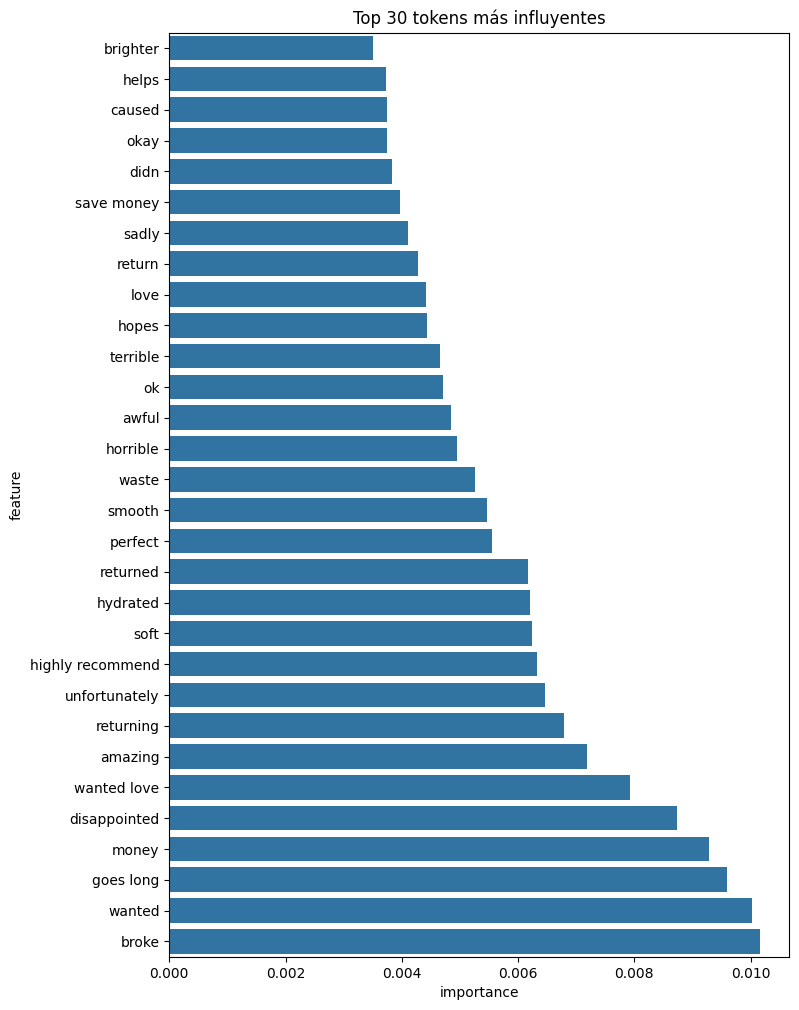

In [19]:
feature_names = vectorizer.get_feature_names_out()
importances = xgb_clf.feature_importances_

top_idx = importances.argsort()[::-1][:30]   # top 30
top_features = feature_names[top_idx]
top_scores = importances[top_idx]

import pandas as pd
df_imp = pd.DataFrame({"feature": top_features, "importance": top_scores})

plt.figure(figsize=(8,12))
sns.barplot(data=df_imp.sort_values("importance"),
            x="importance", y="feature")
plt.title("Top 30 tokens más influyentes")
plt.show()


In [20]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(xgb_clf, "models/model2_xgb.pkl")
joblib.dump(vectorizer, "models/model2_tfidf.pkl")

print("Modelos guardados correctamente.")


Modelos guardados correctamente.
